In [7]:
import numpy as np
import pandas as pd

# 加载 .npz 文件
data = np.load('../multiset/p3ht_ms_ttn_32.npz',allow_pickle=True)

# 'mol list', 'tempearture', 'total time', 'other info', 'r square array', 
# 'electron occupations array', 'phonon occupations array', 'k occupations array', 
# 'eph entropy', 'bond entropy', 'coherent length array', 'time series'
df = data['e_occupations']

df = pd.DataFrame(df)
print(df)
df.to_excel('p3ht_32_multiset.xlsx', index=False)

           0         1         2             3             4             5   \
0    1.000000  0.000000  0.000000  0.000000e+00  0.000000e+00  0.000000e+00   
1    0.889752  0.021852  0.000129  3.327982e-07  4.827289e-10  4.472915e-13   
2    0.616699  0.074106  0.001850  1.969700e-05  1.161723e-07  4.352226e-10   
3    0.316773  0.126336  0.007843  1.969574e-04  2.686086e-06  2.305000e-08   
4    0.118240  0.152415  0.019344  9.222907e-04  2.323066e-05  3.633500e-07   
..        ...       ...       ...           ...           ...           ...   
196  0.043053  0.014948  0.012289  9.120163e-03  8.096949e-03  1.222878e-02   
197  0.043052  0.014940  0.012358  8.953572e-03  8.126946e-03  1.204673e-02   
198  0.043053  0.014930  0.012438  8.758057e-03  8.158256e-03  1.174060e-02   
199  0.043055  0.014895  0.012546  8.542864e-03  8.183588e-03  1.128191e-02   
200  0.043059  0.014803  0.012702  8.314154e-03  8.198214e-03  1.071912e-02   

               6             7             8       

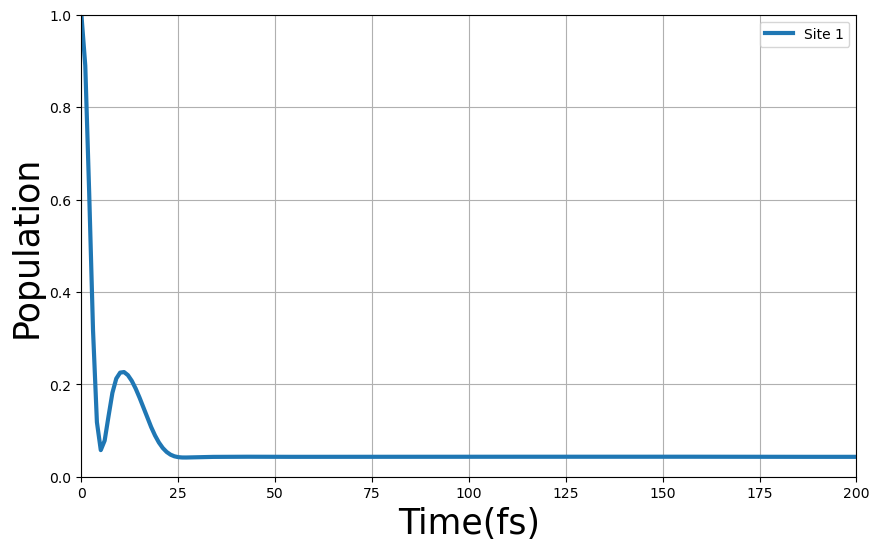

In [9]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

excel_path = Path('p3ht_32_multiset.xlsx')

if not excel_path.exists():
    print(f'Skip: {excel_path} does not exist')
else:
    # 读取Excel文件
    df = pd.read_excel(excel_path)
    # df = pd.read_excel('../../fmo_benchmark.xlsx')

    # 提取数据
    x = np.arange(0,df.shape[0],1)
    x = x * 1 

    y_columns = df.iloc[:, 0:1]  # 第1-7列作为y坐标

    # 创建图表
    plt.figure(figsize=(10, 6))

    # 绘制七条线
    for i in range(0,y_columns.shape[1]):
        plt.plot(x, y_columns.iloc[:, i],label=f'Site {i+1}',linewidth=3)

    # 添加图表元素
    plt.xlabel('Time(fs)',size = 25)
    plt.ylabel('Population',size = 25)
    plt.xlim((0, 200))
    plt.ylim((0, 1))
    plt.title('')
    plt.legend()
    plt.grid(True)

    # 显示图表
    plt.show()

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datasets = [
    # ('16', 'p3ht_16_multiset.xlsx', 'p3ht_16_singleset.xlsx'),
    ('32', 'p3ht_32_multiset.xlsx', 'p3ht_32_singleset.xlsx'),
    # ('64', 'p3ht_64_multiset.xlsx', 'p3ht_64_singleset.xlsx'),
    # ('128', 'p3ht_128_multiset.xlsx', 'p3ht_128_singleset.xlsx'),
]

colors = {'16': 'tab:blue', '32': 'tab:orange', '64': 'tab:green', '128': 'tab:red'}
zoom_start, zoom_end = 150, 200
zoom_values = []
plotted = False

fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.12},
)

for size, multiset_file, singleset_file in datasets:
    multiset_path = Path(multiset_file)
    singleset_path = Path(singleset_file)
    color = colors[size]

    if singleset_path.exists():
        df_single = pd.read_excel(singleset_path)
        x_single = np.arange(df_single.shape[0])
        y_single = df_single.iloc[:, 0:1].iloc[:, 0]
        zoom_values.extend(y_single[(x_single >= zoom_start) & (x_single <= zoom_end)].tolist())

        ax.plot(x_single, y_single, color=color, linewidth=2.5, label=f'{size} singleset')
        ax_zoom.plot(x_single, y_single, color=color, linewidth=2.5)
        plotted = True
    else:
        print(f'Skip {size} singleset: missing {singleset_path}')

    if multiset_path.exists():
        df_multi = pd.read_excel(multiset_path)
        x_multi = np.arange(df_multi.shape[0])
        y_multi = df_multi.iloc[:, 0:1].iloc[:, 0]
        zoom_values.extend(y_multi[(x_multi >= zoom_start) & (x_multi <= zoom_end)].tolist())

        ax.plot(
            x_multi,
            y_multi,
            color=color,
            linestyle='None',
            marker='^',
            markersize=3,
            markevery=2,
            label=f'{size} multiset',
        )
        ax_zoom.plot(
            x_multi,
            y_multi,
            color=color,
            linestyle='None',
            marker='^',
            markersize=5,
            markevery=2,
        )
        plotted = True
    else:
        print(f'Skip {size} multiset: missing {multiset_path}')


benchmark_path = Path("../2026Further_plot/figures/Tree5.npz")
if not benchmark_path.exists():
    benchmark_path = Path("multiset_ttn/P3HT:PCBM/2026Further_plot/figures/Tree5.npz")

if benchmark_path.exists():
    try:
        benchmark_npz = np.load(benchmark_path)
        benchmark_idx = benchmark_npz["M"].astype(str).tolist().index("256")
        y_benchmark = benchmark_npz["n"][benchmark_idx, 0]
        x_benchmark = np.arange(len(y_benchmark))
        zoom_values.extend(y_benchmark[(x_benchmark >= zoom_start) & (x_benchmark <= zoom_end)].tolist())

        ax.plot(
            x_benchmark,
            y_benchmark,
            color="black",
            linestyle="--",
            linewidth=2.5,
            label="Tree M=256 benchmark",
        )
        ax_zoom.plot(
            x_benchmark,
            y_benchmark,
            color="black",
            linestyle="--",
            linewidth=2.5,
        )
        plotted = True
    except (KeyError, ValueError, IndexError) as exc:
        print(f"Skip Tree M=256 benchmark: invalid {benchmark_path}: {exc}")
else:
    print(f"Skip Tree M=256 benchmark: missing {benchmark_path}")

if not plotted:
    plt.close(fig)
    print('Skip plot: no dataset files found')
else:
    ax.set_xlabel('Time(fs)', size=18)
    ax.set_ylabel('Population', size=18)
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax_zoom.set_xlim(zoom_start, zoom_end)
    if zoom_values:
        zoom_min = min(zoom_values)
        zoom_max = max(zoom_values)
        zoom_margin = max((zoom_max - zoom_min) * 0.1, 1e-4)
        ax_zoom.set_ylim(zoom_min - zoom_margin, zoom_max + zoom_margin)
    ax_zoom.set_ylim(0.06, 0.14)
    ax_zoom.set_ylabel('Population', size=18)
    ax_zoom.set_title('150-200 fs', size=14)
    ax_zoom.grid(True, alpha=0.3)

    plt.show()
